[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AveriX26/ML-Course-2026/blob/main/zad_dom_9.ipynb)

In [2]:
import torch

N = 100
focus1 = torch.tensor([-2.0, 0.0])             # First focus,                        sized (2)
points = torch.rand((N, 2)) * 10 - 5           # Uniformly distributed in [-5, 5]    sized (N, 2)

############### when we computed distances to focal points ##############################
dist1 = torch.norm(points - focus1, dim=1)     # the focus 1 gets expanded to (1, 2) then broadcasted to (N, 2)
                                               # to match the points tensor

                                               # effectively what happens is that
                                               # the focus point gets substracted from every other point

                                               # also: note how natural this notation feels here

############### when we computed pairwise point-to-point distances #####################
# Compute all pairwise distances in parallel
print(points.unsqueeze(1).size())                   # sized: (N, 1, 2)
print(points.unsqueeze(0).size())                   # sized: (1, N, 2)

diffs = points.unsqueeze(1) - points.unsqueeze(0)   # sized: (N, N, 2) because of broadcasting
distances = torch.norm(diffs, dim=-1)               # sized: (N, N)

print(distances.size())                             # N x N


torch.Size([100, 1, 2])
torch.Size([1, 100, 2])
torch.Size([100, 100])


# Multi Layer Perceptron (MLP) Diagram
------------------

![network diagram](https://raw.githubusercontent.com/SzymonNowakowski/Machine-Learning-2025/refs/heads/master/MLP_diagram.jpg)

# Reading MNIST Dataset to Play with It
--------------------

In [3]:
import torch
import torchvision
from matplotlib import pyplot

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=None)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 406kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


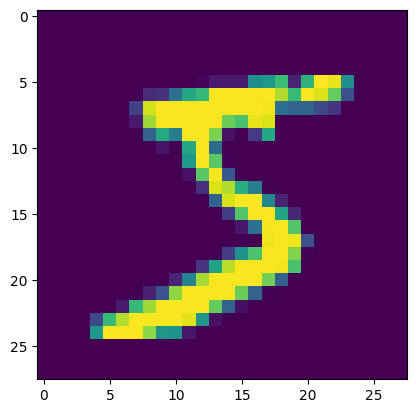

In [4]:
train_image, train_target = trainset[0]    #let us examine the 0-th sample
pyplot.imshow(train_image)
pyplot.show()

In [5]:
trainset.data[0]     #it will be shown in two rows, so a human has hard time classificating it

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [6]:
trainset[0][1]    #check if you classified it correctly in your mind

5

# Rereading the MNIST Data (Serious Preparation for Training)
------------------

In [7]:
(trainset.data.numpy().mean()/255.0, trainset.data.numpy().std()/255.0)   #MNIST datapoints are RGB integers 0-255

(np.float64(0.1306604762738429), np.float64(0.30810780385646264))

# Task
---------------

Why do we need to normalize the data, and not feed the NN with the 0-255 integers?

In [8]:
transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

## Visualizing Data


### Labels (Ground Truth Outputs)

In [9]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i<5:
            print(i, "-th batch labels :", batch_labels)

0 -th batch labels : tensor([2, 1, 1,  ..., 3, 7, 1])
1 -th batch labels : tensor([6, 1, 5,  ..., 0, 4, 2])
2 -th batch labels : tensor([4, 9, 6,  ..., 1, 1, 3])
3 -th batch labels : tensor([8, 0, 2,  ..., 5, 0, 8])
4 -th batch labels : tensor([1, 8, 2,  ..., 4, 9, 2])


A single label is an entity of order zero (a constant), but batched labels are of order one. The first (and only) index is a sample index within a batch.

### Inputs

In [10]:
for i, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        if i==0:
            print(i, "-th batch inputs :", batch_inputs)

0 -th batch inputs : tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
     

OK, so each data image was initially a two dimensional image when we first saw it, but now the batches have order 4. The first index is a sample index within a batch, but a second index is always 0. This index represents a Channel number inserted here by `ToTensor()` transformation, always 0. As this order is one-dimensional, we can get rid of it, later, in training, in `Flatten` layer or by using `squeeze()` on a tensor.

# MLP Definition
-----------------

Your job now is to take the (fully functional) definition of the MLP structure and get rid off the Sequential layer.


In [11]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = torch.nn.Sequential(   #Sequential is a structure which allows stacking layers one on another in such a way,
                                          #that output from a preceding layer serves as input to the next layer
            torch.nn.Flatten(),   #change the last three orders in data (with dimensions 1, 28 and 28 respectively) into one order of dimensions (1*28*28)
            torch.nn.Linear(1*28*28, 1024),  #which is used as INPUT to the first Linear layer
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),   #IMPORTANT! Please observe, that the OUTPUT dimension of a preceding layer is always equal to the INPUT dimension of the next layer.
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 256),
            torch.nn.ReLU(),            #ReLU (or a Sigmoid if you want) is a nonlinear function which is used in-between layers
            torch.nn.Linear(256, 10),
        )
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.mlp(x)
        x = self.dropout(x)
        return x

In [12]:
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten()
        self.linear1 = torch.nn.Linear(1*28*28, 1024)

        self.linear2 = torch.nn.Linear(1024, 2048)
        self.linear3 = torch.nn.Linear(2048, 256)
        self.linear4 = torch.nn.Linear(256, 10)

        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.flatten(x)

        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.relu(self.linear3(x))
        x = self.linear4(x)

        x = self.dropout(x)
        return x

# Training Loop
----------------------

In [13]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(8):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        #batch_inputs.squeeze(1)     #alternatively if not for a Flatten layer, squeeze() could be used to remove the second order of the tensor, the Channel, which is one-dimensional (this index can be equal to 0 only)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the MLP object. Please note, that the last layer of the MLP is linear
                                            #and MLP doesn't apply
                                            #the nonlinear activation after the last layer
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.304421901702881
epoch: 0 batch: 1 current batch loss: 2.076712131500244
epoch: 0 batch: 2 current batch loss: 1.610513687133789
epoch: 0 batch: 3 current batch loss: 1.1400861740112305
epoch: 0 batch: 4 current batch loss: 1.066650629043579
epoch: 0 batch: 5 current batch loss: 1.2121671438217163
epoch: 0 batch: 6 current batch loss: 1.147357702255249
epoch: 0 batch: 7 current batch loss: 0.7138735055923462
epoch: 0 batch: 8 current batch loss: 0.7868716716766357
epoch: 0 batch: 9 current batch loss: 0.8159664869308472
epoch: 0 batch: 10 current batch loss: 0.660053014755249
epoch: 0 batch: 11 current batch loss: 0.5279004573822021
epoch: 0 batch: 12 current batch loss: 0.5414386987686157
epoch: 0 batch: 13 current batch loss: 0.5579782724380493
epoch: 0 batch: 14 current batch loss: 0.5985662341117859
epoch: 0 batch: 15 current batch loss: 0.49392256140708923
epoch: 0 batch: 16 current batch loss: 0.43064820766448975
epoch: 0 bat

# Testing
----------------------

Correct the code below so it works.

In [17]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution
    for batch, data in enumerate(testloader):
        datapoint, label = data

        # POPRAWKA: Przenosimy dane na to samo urządzenie co sieć (GPU/CUDA)
        datapoint = datapoint.to(device)
        label = label.to(device)

        prediction = net(datapoint)
        classification = torch.argmax(prediction)

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9814


# **Homework Assignment - *Do Androids Dream of Electric Sheep?***

-------------------------------------  

"Do Androids Dream of Electric Sheep?" – the famous title of Philip K. Dick’s novel – raises a fascinating question: if artificial intelligence could dream, what would it see?  

In this assignment, we explore a phenomenon known as **neural network dreams**, where instead of optimizing a neural network's weights, we **optimize the input itself** to achieve a desired classification outcome. Given a fully trained MNIST classification network, your goal is to manipulate its inputs so that it confidently predicts each digit from 0 to 9, starting from pure noise.  

## **Tasks Description**  

During this class we designed and trained a **MNIST classification neural network**, which takes a **batch of grayscale images** of size **$28 \times 28$** as input and outputs a probability distribution over the 10 digit classes (0–9). However, instead of using real MNIST images, you will **treat the input batch itself as a set of trainable parameters** and optimize it so that the network classifies each image as a specific digit.  

1. Your first task is to generate **a batch of 10 images**, where each image is
   classified as one of the digits **0, 1, 2, ..., 9**, starting from an initial batch of ten **random Gaussian noise images**.  

   Discuss the following question: do the generated images resemble real MNIST digits? Why or why not?  

2. Discuss, how you would approach a second task of
   generating an image that   
   bares similarity to two or more digits simultaneously. **Implement your idea to see the results.**

3. Third task: repeat the previous tasks with an additional L2 penalty on noise within the images. Experiment with adding `lambda_l2 * dreamed_input_batch.pow(2).mean()` loss term, with `lambda_l2` being the penalty cooefficient within an exponential progression, say from 0.001 to 10.0. Are the new digits recognized correctly? How does the penalty impact the digit quality? Explain.

### **Optimization Process for Task 1**  

1. Start with a **batch of 10 random Gaussian noise images** as the initial input and $(0, 1, 2, \ldots, 9)$ as the expected output batch of target digits.  
2. Define the objective: maximize the neural network's confidence for the corresponding target digit for each image in the batch.  
3. Use **gradient descent** to modify the pixels in each image, making the network classify each one as the assigned digit.  
4. Repeat until the network assigns suffieciently high confidence to each image’s target class.  

### **Implementation Details**  

- The neural network weights **must remain frozen** during optimization. You are modifying only the input images.  
- The loss function should be the **cross-entropy loss** between the predicted probabilities and the desired class labels (plus an optional weighted L2 penalty regularizing the images in task 3).


## **Points to Note**  

1. **Visualize** the optimization process: Save images of the generated inputs at different steps and plot the classification confidence evolution over iterations.  
3. **Document your findings** and explain the behavior you observe.  

## **Task & Deliverables**  

- A **Colab notebook** containing solutions for both tasks:
  - The full implementation.
  - Visualizations of the generated batch of images.
  - A written explanation of your observations.
- **Bonus:** If you create an **animation** showing the evolution of the input images during optimization, it will be considered a strong enhancement to your submission.
  - You can generate an animation programmatically (e.g., using Matplotlib or OpenCV).
  - Or, save image frames and use external tools to create a video.
  - Provide a **link** to any video files in the README.
- Upload your notebook and results to your **GitHub repository** for the course.
- In the **README**, include a **link** to the notebook.
- In the notebook, include **“Open in Colab”** badge so it can be launched directly.




In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

net.eval()
for param in net.parameters():
    param.requires_grad = False

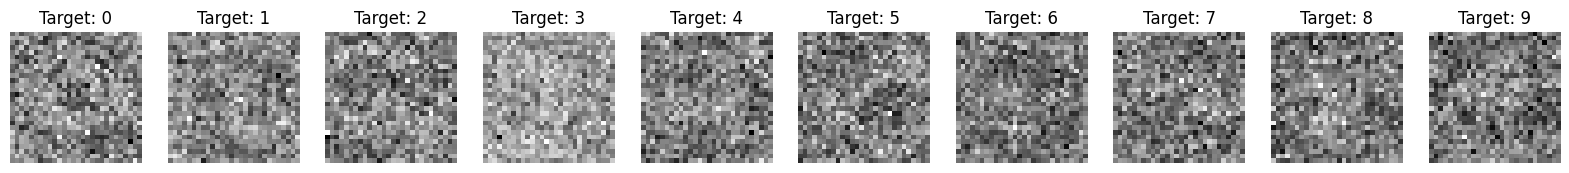


Pewność sieci dla wygenerowanych obrazów:
Docelowo 0 -> Sieć widzi: 0 (Pewność: 100.0000%)
Docelowo 1 -> Sieć widzi: 1 (Pewność: 99.9998%)
Docelowo 2 -> Sieć widzi: 2 (Pewność: 100.0000%)
Docelowo 3 -> Sieć widzi: 3 (Pewność: 100.0000%)
Docelowo 4 -> Sieć widzi: 4 (Pewność: 100.0000%)
Docelowo 5 -> Sieć widzi: 5 (Pewność: 100.0000%)
Docelowo 6 -> Sieć widzi: 6 (Pewność: 100.0000%)
Docelowo 7 -> Sieć widzi: 7 (Pewność: 100.0000%)
Docelowo 8 -> Sieć widzi: 8 (Pewność: 100.0000%)
Docelowo 9 -> Sieć widzi: 9 (Pewność: 100.0000%)


In [19]:
dreamed_batch = torch.randn((10, 1, 28, 28), device=device, requires_grad=True)

targets = torch.arange(10, device=device)

optimizer_input = torch.optim.Adam([dreamed_batch], lr=0.1)

epochs = 1000
history = []

for epoch in range(epochs):
    optimizer_input.zero_grad()

    outputs = net(dreamed_batch)
    loss = F.cross_entropy(outputs, targets)

    loss.backward()
    optimizer_input.step()

    if epoch % 100 == 0:
        history.append(dreamed_batch.detach().cpu().clone())

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
final_images = dreamed_batch.detach().cpu().numpy()

for i in range(10):
    axes[i].imshow(final_images[i, 0], cmap='gray')
    axes[i].set_title(f"Target: {i}")
    axes[i].axis('off')
plt.show()

with torch.no_grad():
    final_outputs = net(dreamed_batch)
    final_probs = F.softmax(final_outputs, dim=1)

print("\nPewność sieci dla wygenerowanych obrazów:")
for i in range(10):
    prob = final_probs[i, i].item() * 100

    predicted_class = torch.argmax(final_probs[i]).item()

    print(f"Docelowo {i} -> Sieć widzi: {predicted_class} (Pewność: {prob:.4f}%)")

In [ ]:
\

Odpowiedź na pytanie z zadania:
Czy wygenerowane obrazy przypominają prawdziwe cyfry MNIST? Dlaczego tak lub dlaczego nie?

Nie, wygenerowane obrazy w ogóle nie przypominają ludzkiego pisma. Zamiast pociągnięć długopisu, przypominają chaotyczny, wysokoczęstotliwościowy szum.
Dlaczego? Dzieje się tak, ponieważ sieć MLP to model dyskryminatywny, a nie generatywny. Sieć nie nauczyła się, "jak wygląda cyfra 8", lecz "jakie cechy pikseli pozwalają odróżnić 8 od innych cyfr". Optymalizując piksele bez ograniczeń, znajdujemy najkrótszą matematyczną ścieżkę do aktywacji odpowiedniego neuronu. Sieć maksymalizuje pewność siebie za pomocą szumu, który dla jej wag stanowi idealny sygnał dla danej klasy.

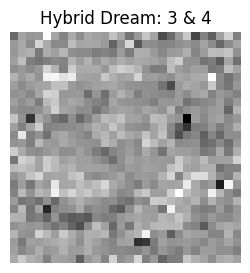

Prawdopodobieństwo dla 3: 72.53%
Prawdopodobieństwo dla 4: 27.47%


In [20]:
class_A = 3
class_B = 4

hybrid_dream = torch.randn((1, 1, 28, 28), device=device, requires_grad=True)
optimizer_hybrid = torch.optim.Adam([hybrid_dream], lr=0.1)

for epoch in range(500):
    optimizer_hybrid.zero_grad()
    outputs = net(hybrid_dream)


    logit_A = outputs[0, class_A]
    logit_B = outputs[0, class_B]

    loss = - (logit_A + logit_B) + 5.0 * torch.abs(logit_A - logit_B)

    loss.backward()
    optimizer_hybrid.step()

plt.figure(figsize=(3,3))
plt.imshow(hybrid_dream.detach().cpu().numpy()[0, 0], cmap='gray')
plt.title(f"Hybrid Dream: {class_A} & {class_B}")
plt.axis('off')
plt.show()

final_probs = F.softmax(net(hybrid_dream), dim=1)[0].detach().cpu().numpy()
print(f"Prawdopodobieństwo dla {class_A}: {final_probs[class_A]*100:.2f}%")
print(f"Prawdopodobieństwo dla {class_B}: {final_probs[class_B]*100:.2f}%")



Moje pierwsze, intuicyjne podejście polegało na maksymalizowaniu sumy surowych wartości wyjściowych (logitów) dla obu tych klas: loss = - (logit_A + logit_B).
Niestety, takie podejście doprowadziło do sytuacji, w której optymalizator poszedł po linii najmniejszego oporu czyli znalazł cechy ułatwiające rozpoznanie jednej z cyfr i podbił jej prawdopodobieństwo do 100%, całkowicie ignorując drugą (0%).
Aby powstrzymać optymalizator przed faworyzowaniem jednej z klas, konieczne było nałożenie dodatkowej kary za różnicę między logitami. Ostateczna funkcja straty użyta w eksperymencie przybrała postać:
loss = - (logit_A + logit_B) + 5.0 * torch.abs(logit_A - logit_B)

Dzięki dodaniu członu z wartością bezwzględną, algorytm był karany za każdym razem, gdy jedna klasa zaczynała dominować nad drugą, co zmusiło go do budowania w szumie wejściowym cech obu cyfr


--- Pewność sieci dla λ = 0.001 ---
Cel 0 -> Widzi: 0 (100.00%)	| Cel 1 -> Widzi: 1 (100.00%)
Cel 2 -> Widzi: 2 (100.00%)	| Cel 3 -> Widzi: 3 (100.00%)
Cel 4 -> Widzi: 4 (100.00%)	| Cel 5 -> Widzi: 5 (100.00%)
Cel 6 -> Widzi: 6 (100.00%)	| Cel 7 -> Widzi: 7 (100.00%)
Cel 8 -> Widzi: 8 (100.00%)	| Cel 9 -> Widzi: 9 (100.00%)

--- Pewność sieci dla λ = 0.01 ---
Cel 0 -> Widzi: 0 (99.99%)	| Cel 1 -> Widzi: 1 (100.00%)
Cel 2 -> Widzi: 2 (100.00%)	| Cel 3 -> Widzi: 3 (100.00%)
Cel 4 -> Widzi: 4 (100.00%)	| Cel 5 -> Widzi: 5 (100.00%)
Cel 6 -> Widzi: 6 (100.00%)	| Cel 7 -> Widzi: 7 (100.00%)
Cel 8 -> Widzi: 8 (99.99%)	| Cel 9 -> Widzi: 9 (99.99%)

--- Pewność sieci dla λ = 0.1 ---
Cel 0 -> Widzi: 0 (99.96%)	| Cel 1 -> Widzi: 1 (99.98%)
Cel 2 -> Widzi: 2 (99.98%)	| Cel 3 -> Widzi: 3 (99.97%)
Cel 4 -> Widzi: 4 (99.96%)	| Cel 5 -> Widzi: 5 (99.98%)
Cel 6 -> Widzi: 6 (99.97%)	| Cel 7 -> Widzi: 7 (99.97%)
Cel 8 -> Widzi: 8 (99.94%)	| Cel 9 -> Widzi: 9 (99.96%)

--- Pewność sieci dla λ = 1.0 ---


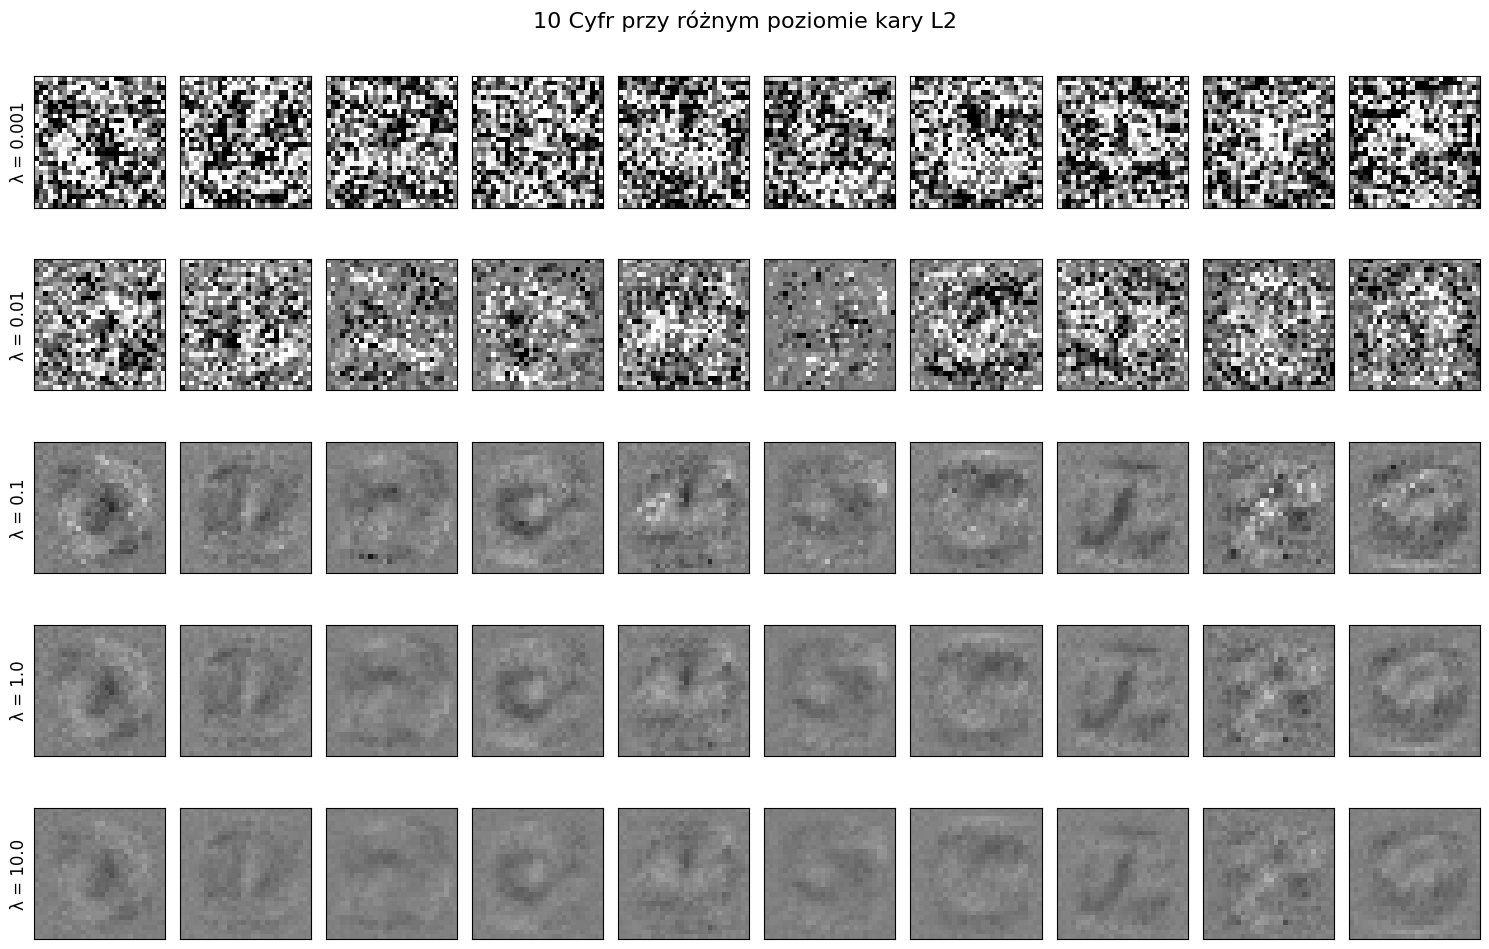

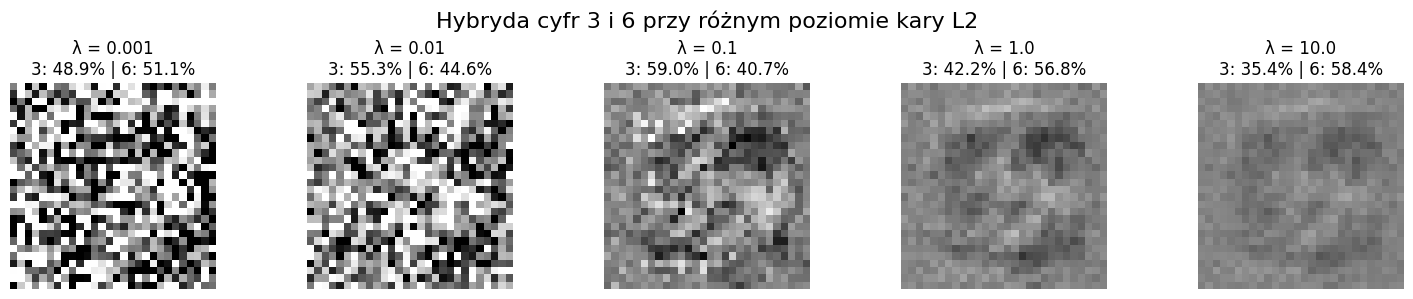

In [22]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

lambdas = [0.001, 0.01, 0.1, 1.0, 10.0]

fig1, axes1 = plt.subplots(len(lambdas), 10, figsize=(15, 2 * len(lambdas)))
targets_10 = torch.arange(10, device=device)

for row_idx, lambda_l2 in enumerate(lambdas):
    dreamed_10 = torch.randn((10, 1, 28, 28), device=device, requires_grad=True)
    optimizer_10 = torch.optim.Adam([dreamed_10], lr=0.1)

    for epoch in range(1000):
        optimizer_10.zero_grad()
        outputs = net(dreamed_10)

        loss_class = F.cross_entropy(outputs, targets_10)
        loss_l2 = lambda_l2 * dreamed_10.pow(2).mean()
        loss = loss_class + loss_l2

        loss.backward()
        optimizer_10.step()

    final_images = dreamed_10.detach().cpu().numpy()

    with torch.no_grad():
        final_probs = F.softmax(net(dreamed_10), dim=1)

    print(f"\n--- Pewność sieci dla λ = {lambda_l2} ---")
    for i in range(10):
        prob = final_probs[i, i].item() * 100
        pred = torch.argmax(final_probs[i]).item()
        print(f"Cel {i} -> Widzi: {pred} ({prob:.2f}%)", end="\t| " if i % 2 == 0 else "\n")

    for i in range(10):
        axes1[row_idx, i].imshow(final_images[i, 0], cmap='gray', vmin=-1, vmax=1)
        axes1[row_idx, i].set_xticks([])
        axes1[row_idx, i].set_yticks([])
        if i == 0:
            axes1[row_idx, i].set_ylabel(f"λ = {lambda_l2}", fontsize=12)

fig1.suptitle("10 Cyfr przy różnym poziomie kary L2", fontsize=16)
plt.tight_layout()
plt.show()


class_A, class_B = 3, 6

target_probs = torch.zeros((1, 10), device=device)
target_probs[0, class_A] = 0.5
target_probs[0, class_B] = 0.5

fig2, axes2 = plt.subplots(1, len(lambdas), figsize=(15, 3))

for idx, lambda_l2 in enumerate(lambdas):
    hybrid_dream = torch.randn((1, 1, 28, 28), device=device, requires_grad=True)
    optimizer_hybrid = torch.optim.Adam([hybrid_dream], lr=0.1)

    for epoch in range(1000):
        optimizer_hybrid.zero_grad()
        outputs = net(hybrid_dream)

        loss_class = F.cross_entropy(outputs, target_probs)
        loss_l2 = lambda_l2 * hybrid_dream.pow(2).mean()
        loss = loss_class + loss_l2

        loss.backward()
        optimizer_hybrid.step()

    final_hybrid = hybrid_dream.detach().cpu().numpy()[0, 0]

    final_preds = F.softmax(net(hybrid_dream), dim=1)[0].detach().cpu().numpy()

    axes2[idx].imshow(final_hybrid, cmap='gray', vmin=-1, vmax=1)
    axes2[idx].set_title(f"λ = {lambda_l2}\n3: {final_preds[class_A]*100:.1f}% | 6: {final_preds[class_B]*100:.1f}%")
    axes2[idx].axis('off')

fig2.suptitle(f"Hybryda cyfr {class_A} i {class_B} przy różnym poziomie kary L2", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
fig_anim, axes_anim = plt.subplots(1, 10, figsize=(15, 1.5))

plots = []
for i in range(10):
    axes_anim[i].axis('off')
    p = axes_anim[i].imshow(history[0][i, 0].numpy(), cmap='gray', animated=True)
    axes_anim[i].set_title(str(i))
    plots.append(p)

plt.close()

def update(frame):
    current_data = history[frame]
    for i in range(10):
        plots[i].set_array(current_data[i, 0].numpy())
    return plots

ani = animation.FuncAnimation(fig_anim, update, frames=len(history), interval=200, blit=True)

HTML(ani.to_html5_video())

1. Zmiana jakości wizualnej
Wbrew pozorom, wzrost kary L2 nie niszczy obrazu, lecz ujawnia wewnętrzną reprezentację cyfr, co doskonale widać na załączonych wynikach:

* Mała kara ($\lambda = 0.001 - 0.01$): Obrazy są całkowicie nieczytelne dla człowieka. Składają się z ostrego, wysokoczęstotliwościowego czarno-białego szumu.
* Średnia i wysoka kara ($\lambda = 0.1 - 10.0$): Ostre, czarno-białe piksele znikają na rzecz gładkiego, szarego tła. Co najważniejsze, z szumu wyłaniają się czytelne dla ludzkiego oka zarysy konkretnych cyfr. W ostatnim wierszu ($\lambda = 10.0$) bez problemu możemy wzrokowo rozpoznać niemal wszystkie docelowe klasy.

2. Skuteczność klasyfikacji (Paradoks percepcji)
Pomiary pewności sieci pokazują fascynujący paradoks:

* Kiedy obrazy są dla nas całkowitym, nieczytelnym szumem ($\lambda = 0.001$), sieć jest w 100% pewna swoich wyników.
* Kiedy obrazy stają się wygładzone i najbardziej czytelne dla ludzkiego oka ($\lambda = 10.0$), pewność sieci paradoksalnie spada do poziomu ~97-98%. Oznacza to, że gładki obraz przypominający cyfrę jest dla samej sieci *mniej* optymalnym sygnałem niż chaotyczny szum.

3. Dlaczego tak się dzieje?

* Brak kary: Bez kary L2, optymalizator używa skrajnie jasnych i ciemnych pikseli punktowo, aby jak najszybciej i najniższym kosztem zmaksymalizować aktywację sieci, całkowicie ignorując ludzki wygląd cyfry.
* Silna kara L2: Kara L2 nakłada potężny koszt na skrajne wartości pikseli. Optymalizator nie może już oszukiwać pojedynczymi, jaskrawymi pikselami. Aby aktywować neuron przy wysokiej karze L2, optymalizator musi rozłożyć sygnał równomiernie na wszystkie piksele, które sieć uważa za ważne dla danej klasy. Szum znika, a my nareszcie widzimy to, jak sieć wyobraża sobie daną cyfrę.

4. Wpływ na hybrydę
W przypadku hybrydy ("3" i "6"), silna regularyzacja L2 działa analogicznie czyli pozbywa się śmieciowego szumu i wymusza na optymalizatorze wyrysowanie na szarym tle gładkiego "kompromisu" wagowego dla obu cyfr. Ponieważ jednak wagi dla "3" i "6" są częściowo sprzeczne w różnych miejscach obrazu, przy najwyższej karze ($\lambda = 10.0$) zbalansowanie ich dokładnie w stosunku 50/50 staje się dla sieci znacznie trudniejsze.